In [1]:
# === ノートブック共通の前処理 (llm_math パッケージの読み込み) ===
import sys
from pathlib import Path

# llm_math パッケージの候補パス
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# 親ディレクトリも候補に追加 (notebooks/ フォルダで実行する場合)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# llm_math の import を試行
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[注意] llm_math パッケージの読み込み テキスト: {e}")
    print("  GitHub リポジトリを clone して colab_setup.sh を実行してください。")
# === 前処理ここまで ===


# Ch 10. テキスト テキスト — テキスト 学習 テキスト

> **学習目標**
> - Dropoutテキスト テキスト テキスト テキスト テキスト テキスト テキスト
> - BatchNorm, LayerNorm, RMSNormテキスト テキスト テキスト
> - LLMテキスト LayerNorm/RMSNormテキスト テキスト テキスト テキスト

## 10.1 テキスト テキスト

**テキスト(overfitting)**: 学習 データテキスト テキスト テキスト テキスト データテキスト テキスト テキスト.
- 学習 テキスト ↓, 検証 テキスト ↑ テキスト

テキスト(regularization)テキスト モデル テキスト度テキスト テキスト テキスト テキスト 性能テキスト テキスト.


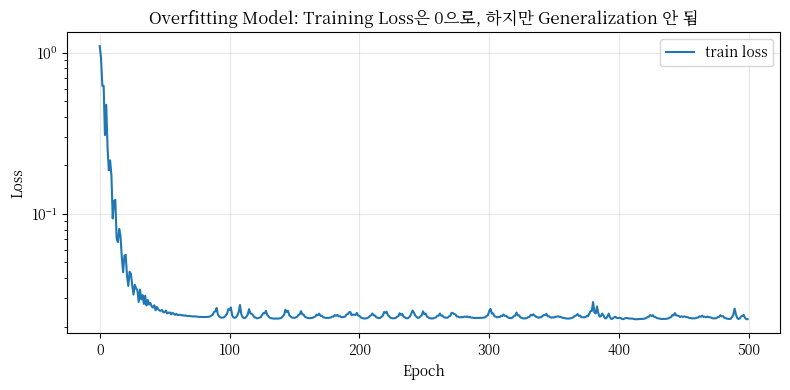

テキスト Training Loss: 0.0223 (テキスト 0)
テキスト テキスト Dataテキスト Performanceテキスト テキスト テキスト.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from llm_math.data import make_spiral_data, load_mnist_small

# テキスト テキスト: テキスト データテキスト テキスト モデル
X_sp, y_sp = make_spiral_data(50, 3)
X_t = torch.tensor(X_sp, dtype=torch.float32)
y_t = torch.tensor(y_sp, dtype=torch.long)

torch.manual_seed(0)
big_model = nn.Sequential(
    nn.Linear(2, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 3)
)
opt = torch.optim.Adam(big_model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
for epoch in range(500):
    opt.zero_grad()
    out = big_model(X_t)
    loss = loss_fn(out, y_t)
    loss.backward()
    opt.step()
    train_losses.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Overfitting Model: Training Lossテキスト 0テキスト, テキスト Generalization テキスト テキスト')
plt.legend(); plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig('../figures/ch10_overfitting.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"テキスト Training Loss: {train_losses[-1]:.4f} (テキスト 0)")
print("テキスト テキスト Dataテキスト Performanceテキスト テキスト テキスト.")


## 10.2 L1, L2 テキスト — テキスト テキスト

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \|\theta\|_2^2 \quad (L^2)$$
$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \|\theta\|_1 \quad (L^1)$$

- $L^2$: テキスト 0テキスト テキスト. テキスト テキスト テキスト テキスト $\theta \sim \mathcal{N}(0, \sigma^2)$テキスト テキスト.
- $L^1$: テキスト テキスト度 (テキスト テキスト テキスト 0). テキスト テキスト テキスト.


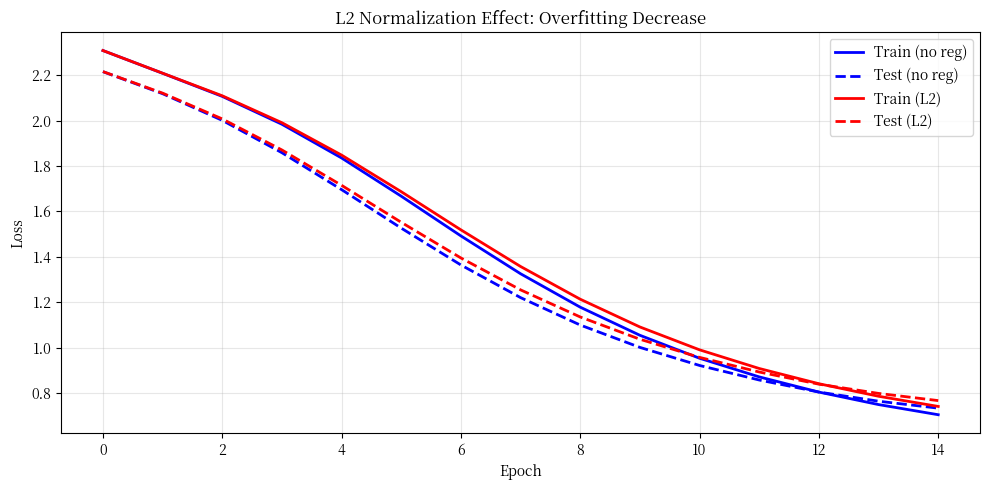

In [3]:
# L2 テキスト テキスト
torch.manual_seed(0)
model_no_reg = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 10)
)
torch.manual_seed(0)
model_l2 = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 10)
)

X_tr, y_tr, X_te, y_te = load_mnist_small(n_train=2000, n_test=1000)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.long)

loss_fn = nn.CrossEntropyLoss()
opt_no = torch.optim.SGD(model_no_reg.parameters(), lr=0.5)
opt_l2 = torch.optim.SGD(model_l2.parameters(), lr=0.5, weight_decay=0.01)

def train(model, opt, n_epochs=20):
    tr_losses, te_losses = [], []
    for _ in range(n_epochs):
        opt.zero_grad()
        out = model(X_tr_t)
        loss = loss_fn(out, y_tr_t)
        loss.backward()
        opt.step()
        tr_losses.append(loss.item())
        with torch.no_grad():
            te_loss = loss_fn(model(X_te_t), y_te_t).item()
            te_losses.append(te_loss)
    return tr_losses, te_losses

tr_no, te_no = train(model_no_reg, opt_no, n_epochs=15)
tr_l2, te_l2 = train(model_l2, opt_l2, n_epochs=15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tr_no, 'b-', label='Train (no reg)', linewidth=2)
ax.plot(te_no, 'b--', label='Test (no reg)', linewidth=2)
ax.plot(tr_l2, 'r-', label='Train (L2)', linewidth=2)
ax.plot(te_l2, 'r--', label='Test (L2)', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('L2 Normalization Effect: Overfitting Decrease')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch10_l2_regularization.png', dpi=100, bbox_inches='tight')
plt.show()


## 10.3 Dropout — テキスト テキスト

学習 テキスト テキスト テキスト $p$テキスト 0テキスト テキスト:
$$\tilde{\mathbf{h}} = \frac{\mathbf{m} \odot \mathbf{h}}{p}, \quad \mathbf{m}_i \sim \mathrm{Bernoulli}(1-p)$$

- $1/p$テキスト テキスト テキスト値 テキスト
- 推論 テキスト dropout テキスト テキスト テキスト (テキスト テキスト テキスト)

テキスト: テキスト テキスト テキスト 学習 → テキスト テキスト. テキスト テキスト co-adaptation テキスト.


Dropout=0.0: テキスト test acc = 82.90%


Dropout=0.3: テキスト test acc = 82.10%


Dropout=0.5: テキスト test acc = 81.50%


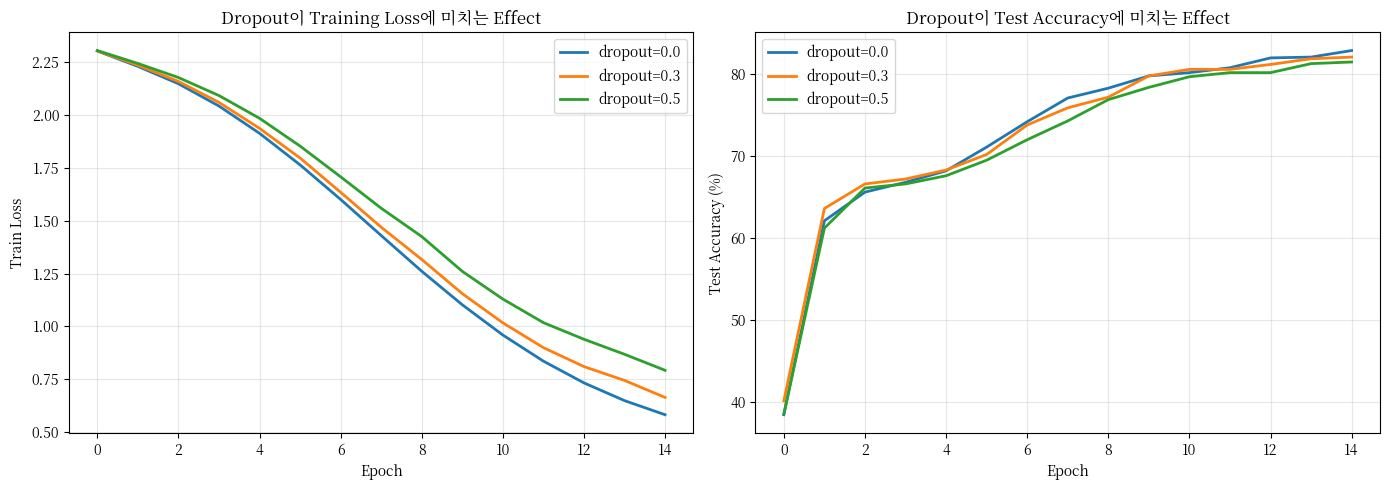

In [4]:
# Dropout テキスト
torch.manual_seed(0)

def make_model(dropout=0.0):
    return nn.Sequential(
        nn.Linear(784, 512), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 10)
    )

results = {}
for dropout in [0.0, 0.3, 0.5]:
    torch.manual_seed(0)
    model = make_model(dropout)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    tr_losses, te_accs = [], []
    for epoch in range(15):
        opt.zero_grad()
        out = model(X_tr_t)
        loss = loss_fn(out, y_tr_t)
        loss.backward()
        opt.step()
        tr_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            pred = model(X_te_t).argmax(1)
            acc = (pred == y_te_t).float().mean().item()
            te_accs.append(acc)
        model.train()
    results[dropout] = (tr_losses, te_accs)
    print(f"Dropout={dropout}: テキスト test acc = {te_accs[-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for d, (tr, te) in results.items():
    axes[0].plot(tr, label=f'dropout={d}', linewidth=2)
    axes[1].plot([a*100 for a in te], label=f'dropout={d}', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Dropoutテキスト Training Lossテキスト テキスト Effect')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Dropoutテキスト Test Accuracyテキスト テキスト Effect')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch10_dropout.png', dpi=100, bbox_inches='tight')
plt.show()


## 10.4 テキスト テキスト (BatchNorm)

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta$$

- $\mu_B, \sigma_B^2$: テキスト テキスト
- $\gamma, \beta$: 学習 テキスト テキスト/テキスト
- "テキスト テキスト テキスト(internal covariate shift)" テキスト (テキスト テキスト テキスト度 テキスト)
- 推論 テキスト: 学習テキスト テキスト テキスト テキスト

**問題**: シーケンス長テキスト テキスト RNN/Transformerテキスト テキスト. テキスト テキスト テキスト.


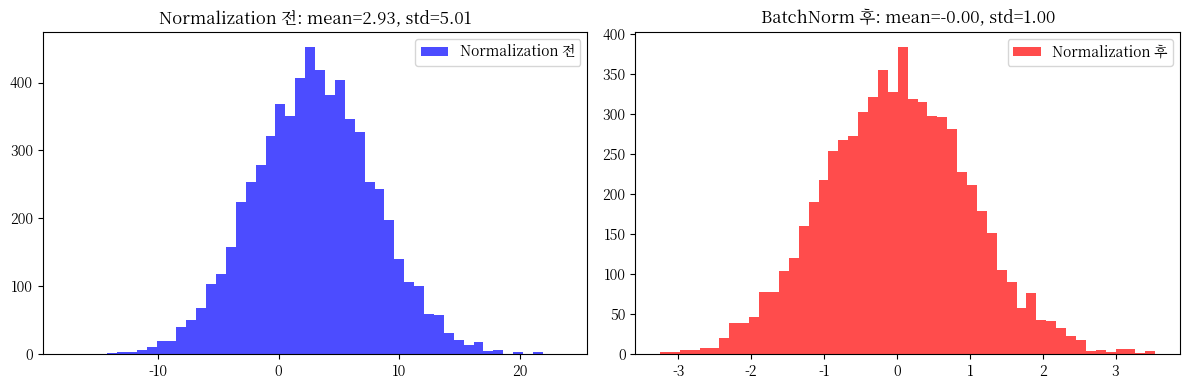

In [5]:
# BatchNorm 可視化
np.random.seed(0)
# テキスト値 分布
import torch.nn.functional as F

torch.manual_seed(0)
x = torch.randn(64, 100) * 5 + 3  # テキスト 3, テキスト 5
bn = nn.BatchNorm1d(100)
y = bn(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x.flatten().numpy(), bins=50, alpha=0.7, color='blue', label='Normalization テキスト')
axes[0].set_title(f'Normalization テキスト: mean={x.mean():.2f}, std={x.std():.2f}')
axes[0].legend()
axes[1].hist(y.detach().flatten().numpy(), bins=50, alpha=0.7, color='red', label='Normalization テキスト')
axes[1].set_title(f'BatchNorm テキスト: mean={y.mean():.2f}, std={y.std():.2f}')
axes[1].legend()
plt.tight_layout()
plt.savefig('../figures/ch10_batchnorm.png', dpi=100, bbox_inches='tight')
plt.show()


## 10.5 テキスト テキスト (LayerNorm) — テキスト テキスト

$$\mu = \frac{1}{d}\sum_i x_i, \quad \sigma^2 = \frac{1}{d}\sum_i (x_i - \mu)^2$$
$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta$$

テキスト:
- **BatchNorm**: テキスト 次元テキスト テキスト テキスト (テキスト featureテキスト)
- **LayerNorm**: feature 次元テキスト テキスト テキスト (テキスト テキスト)

LayerNormテキスト テキスト テキスト テキスト テキスト → テキスト モデルテキスト テキスト. **LLM テキスト**.


In [6]:
# BatchNorm vs LayerNorm 比較
torch.manual_seed(0)
# (batch, features) = (4, 6)
x = torch.tensor([
    [1., 2., 3., 4., 5., 6.],
    [10., 20., 30., 40., 50., 60.],
    [-1., -2., -3., -4., -5., -6.],
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
])

print("Input (batch=4, features=6):")
print(x)

# BatchNorm: featureテキスト テキスト (テキスト テキスト)
bn = nn.BatchNorm1d(6, affine=False)
y_bn = bn(x)
print(f"\nBatchNorm (テキスト feature/テキスト Normalization):")
print(y_bn.round(decimals=3))
print(f"  テキスト テキスト mean ≈ 0, std ≈ 1")

# LayerNorm: テキスト テキスト (テキスト テキスト)
ln = nn.LayerNorm(6, elementwise_affine=False)
y_ln = ln(x)
print(f"\nLayerNorm (テキスト sample/テキスト Normalization):")
print(y_ln.round(decimals=3))
print(f"  テキスト テキスト mean ≈ 0, std ≈ 1")


Input (batch=4, features=6):
tensor([[ 1.0000,  2.0000,  3.0000,  4.0000,  5.0000,  6.0000],
        [10.0000, 20.0000, 30.0000, 40.0000, 50.0000, 60.0000],
        [-1.0000, -2.0000, -3.0000, -4.0000, -5.0000, -6.0000],
        [ 0.1000,  0.2000,  0.3000,  0.4000,  0.5000,  0.6000]])

BatchNorm (テキスト feature/テキスト Normalization):
tensor([[-0.3490, -0.3490, -0.3490, -0.3490, -0.3490, -0.3490],
        [ 1.7090,  1.7090,  1.7090,  1.7090,  1.7090,  1.7090],
        [-0.8060, -0.8060, -0.8060, -0.8060, -0.8060, -0.8060],
        [-0.5540, -0.5540, -0.5540, -0.5540, -0.5540, -0.5540]])
  テキスト テキスト mean ≈ 0, std ≈ 1

LayerNorm (テキスト sample/テキスト Normalization):
tensor([[-1.4640, -0.8780, -0.2930,  0.2930,  0.8780,  1.4640],
        [-1.4640, -0.8780, -0.2930,  0.2930,  0.8780,  1.4640],
        [ 1.4640,  0.8780,  0.2930, -0.2930, -0.8780, -1.4640],
        [-1.4640, -0.8780, -0.2930,  0.2930,  0.8780,  1.4640]])
  テキスト テキスト mean ≈ 0, std ≈ 1


## 10.6 RMSNorm — LayerNormテキスト テキスト

$$\bar{x} = \frac{x}{\sqrt{\frac{1}{d}\sum_i x_i^2 + \epsilon}} \odot \gamma$$

テキスト テキスト テキスト, RMS(root mean square)テキスト テキスト. **LLaMAテキスト テキスト**.

テキスト:
- 計算テキスト テキスト テキスト
- 性能テキスト LayerNormテキスト テキスト
- テキスト テキスト テキスト


In [7]:
# RMSNorm テキスト
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.gamma

# 比較
torch.manual_seed(0)
x = torch.randn(2, 4, 8) * 3 + 1  # (batch, seq, dim)

ln = nn.LayerNorm(8)
rmsn = RMSNorm(8)

y_ln = ln(x)
y_rmsn = rmsn(x)

print(f"Input: shape={x.shape}, mean={x.mean():.4f}, std={x.std():.4f}")
print(f"LayerNorm: mean={y_ln.mean():.4f}, std={y_ln.std():.4f}")
print(f"RMSNorm:   mean={y_rmsn.mean():.4f}, std={y_rmsn.std():.4f}")
print("\n=> LayerNormテキスト mean=0, RMSNormテキスト meanテキスト 0テキスト テキスト テキスト (テキスト)")


Input: shape=torch.Size([2, 4, 8]), mean=1.2781, std=3.1513
LayerNorm: mean=0.0000, std=1.0079
RMSNorm:   mean=0.4170, std=0.9161

=> LayerNormテキスト mean=0, RMSNormテキスト meanテキスト 0テキスト テキスト テキスト (テキスト)


## 10.7 テキスト ノルム テキスト

$$\mathbf{g} \leftarrow \min\left(1, \frac{c}{\|\mathbf{g}\|}\right) \mathbf{g}$$

LLM 学習テキスト テキスト. loss spikeテキスト テキスト テキスト.


In [8]:
# PyTorch テキスト テキスト
torch.manual_seed(0)
model = nn.Linear(10, 5)
x = torch.randn(3, 10)
y = torch.randn(3, 5)

loss = nn.MSELoss()(model(x), y)
loss.backward()

# テキスト テキスト
grad_norm_before = sum((p.grad**2).sum() for p in model.parameters()).sqrt().item()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
grad_norm_after = sum((p.grad**2).sum() for p in model.parameters()).sqrt().item()

print(f"Gradient Norm:")
print(f"  テキスト テキスト: {grad_norm_before:.4f}")
print(f"  テキスト テキスト: {grad_norm_after:.4f} (1.0テキスト テキスト)")


Gradient Norm:
  テキスト テキスト: 2.6053
  テキスト テキスト: 1.0000 (1.0テキスト テキスト)


## 10.8 要点

| テキスト | テキスト | テキスト度 |
|---|---|---|
| $L^2$ テキスト | $\mathcal{L} + \lambda\|\theta\|^2$ | テキスト テキスト |
| $L^1$ テキスト | $\mathcal{L} + \lambda\|\theta\|_1$ | テキスト |
| Dropout | $\frac{\mathbf{m} \odot \mathbf{h}}{p}$ | テキスト テキスト |
| BatchNorm | $\frac{x - \mu_B}{\sigma_B}$ | テキスト テキスト |
| LayerNorm | $\frac{x - \mu}{\sigma}$ (featureテキスト) | LLM テキスト |
| RMSNorm | $\frac{x}{\sqrt{\frac{1}{d}\sum x_i^2}} \gamma$ | LLaMA テキスト |

## 演習問題

1. Dropout $p=0, 0.2, 0.5, 0.8$テキスト テキスト MNIST MLP テキスト テキスト度テキスト 比較テキスト.
2. BatchNormテキスト LayerNormテキスト テキスト MLPテキスト テキスト 学習 テキスト 比較テキスト.
3. RMSNormテキスト LayerNormテキスト テキスト テキスト 比較テキスト (テキスト テキスト テキスト).
4. テキスト テキスト $\lambda = 0, 10^{-4}, 10^{-2}, 10^{-1}$テキスト テキスト 学習 テキスト 比較テキスト.
5. テキスト テキスト テキスト 学習テキスト 学習 テキスト テキスト テキスト テキスト.

> 解答: `solutions/ch10_solutions.ipynb`
